In [56]:
from data.torch import RNNModelScratch
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F

keys = []
for k in sys.modules.keys():
    if "d2l" in k:
        # print(k)
        keys.append(k)
for k in keys:
    del sys.modules[k]
from d2l import torch as d2l

In [2]:
batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 8.5.1 独热编码

In [16]:
F.one_hot(torch.tensor([0, 2]), len(vocab))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])

In [27]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, 28).shape

torch.Size([5, 2, 28])

In [36]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)

    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)

    return params

### 8.5.3 循环神经网络模型

In [29]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)

In [30]:
def rnn(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []

    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)

    return torch.cat(outputs, dim=0), (H,)

In [40]:
num_hiddens = 512
net = d2l.RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params, init_rnn_state, rnn)
state = net.begin_state(X.shape[0], d2l.try_gpu())
Y, new_state = net(X.to(d2l.try_gpu()), state)
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 28]), 1, torch.Size([2, 512]))

### 8.5.4 预测

In [55]:
d2l.predict_ch8("time traveller ", 10, net, vocab, d2l.try_gpu())

'time traveller bouximtazi'

### 8.5.6 训练

/Users/kukudehui/Documents/exec_code/Python/D2DL/.venv/lib/python3.9/site-packages/d2l/torch.py:3428: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


time traveller the the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller the the the the the the the the the the the the t
time traveller and the the the the the the the the the the the t
time traveller and the this the thimens of the the this the thim
time traveller and the the the the the the the the the the the t
time traveller and the the the the the the the the the the the t
time traveller andithe the and he paree the the the the the the 
time traveller and the the that the that the that the that the t
time traveller and the the the the the the the the the the the t
time travelleredicen in the thate thing time tion and the the th
time traveller ching sime time than this this thing sime time ti
time traveller ald he the the in the merecallere hat in the the 
time traveller thene dimensions and the time travely th se che t
time travellerithe ardith

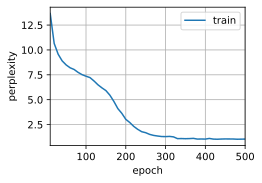

In [57]:
num_epochs, lr = 500, 1
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())

time traveller the the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller the the the the the the the the the the the the t
time traveller and the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller and the the the the the the the the the the the t
time traveller and he the the the the the the the the the the th
time traveller and the the the the the the the the the the the t
time traveller and and and and and and and and and and and and a
time traveller andithe mone the the that in the the that in the 
time traveller andinensions and the thatent the that anowhis the
time traveller the this that as in the psome thave the thice tri
time traveller of in the ond of space the ond chas in th th dime
time traveller dimensions

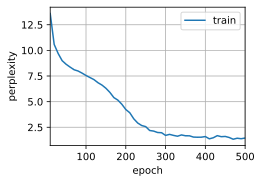

In [60]:
net = d2l.RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params, init_rnn_state, rnn)
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(), use_random_iter=True)